# IBM/Qiskit QAOA Portfolio Rollout Notebook

This notebook follows a sequential rollout:
- Phase 1: fully local verification
- Phase 2: local optimization + final IBM hardware sampling
- Phase 3: optional tiny hardware-in-loop test


## 1. Setup / imports / IBM service setup

One-time IBM Open Plan setup:
```python
from qiskit_ibm_runtime import QiskitRuntimeService
QiskitRuntimeService.save_account(
    token="YOUR_API_KEY",
    plans_preference=["open"],
    region="us-east",
    set_as_default=True,
    overwrite=True,
)
```


In [12]:
from pathlib import Path
from pprint import pprint
import sys
import time

import matplotlib.pyplot as plt
import numpy as np

CURRENT_DIR = Path.cwd().resolve()
if (CURRENT_DIR / "portfolio_qaoa_core.py").exists():
    PROJECT_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / "portfolio_qaoa_core.py").exists():
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    raise FileNotFoundError("Could not locate portfolio_qaoa_core.py from the current working directory.")

IBM_DIR = PROJECT_ROOT / "IBM"
for import_path in (PROJECT_ROOT, IBM_DIR):
    if str(import_path) not in sys.path:
        sys.path.insert(0, str(import_path))

from portfolio_qaoa_core import (
    bruteforce_portfolio_baseline,
    compare_analytical_and_numerical_ising,
    extract_sampling_metrics,
    generate_random_portfolio_instance,
    get_default_worked_example,
    plot_bitstring_distribution,
    plot_optimization_convergence,
    plot_risk_return_scatter,
    portfolio_qubo_coeffs,
    qubo_to_ising,
)
from portfolio_qaoa_qiskit import (
    build_bound_measured_qaoa_circuit,
    build_qiskit_cost_operator,
    counts_to_samples,
    empirical_average_penalized_cost_from_counts,
    estimate_hardware_loop_cost,
    generate_initial_qaoa_parameters,
    get_ibm_runtime_service,
    hardware_loop_warnings,
    plot_local_vs_ibm_probability_comparison,
    run_qaoa_experiment_qiskit,
    sample_fixed_qaoa_circuit,
    save_figure_artifact,
    save_json_artifact,
    select_ibm_backend,
    summarize_run_for_logging,
    summarize_transpiled_bound_qaoa_circuit,
    summarize_transpiled_circuit,
    timestamped_run_id,
)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


## 2. Shared problem configuration


In [13]:
RUN_LOCAL_VERIFICATION = True
RUN_IBM_FINAL_SAMPLING = False
RUN_HARDWARE_IN_LOOP = True

runtime_defaults = {"channel": None, "instance": None, "backend_name": None}
OUTPUT_ROOT = PROJECT_ROOT / "IBM" / "outputs" / "ibm_runs"
RUN_ID = timestamped_run_id(prefix="ibm_rollout")
RUN_OUTPUT_DIR = OUTPUT_ROOT / RUN_ID
RUN_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
artifact_manifest = {
    "run_id": RUN_ID,
    "run_output_dir": str(RUN_OUTPUT_DIR.resolve()),
    "files": {},
    "summaries": {},
    "flags": {
        "RUN_LOCAL_VERIFICATION": RUN_LOCAL_VERIFICATION,
        "RUN_IBM_FINAL_SAMPLING": RUN_IBM_FINAL_SAMPLING,
        "RUN_HARDWARE_IN_LOOP": RUN_HARDWARE_IN_LOOP,
    },
}

def record_artifact(key, path):
    artifact_manifest["files"][key] = str(path)
    return path

def record_summary(key, payload):
    artifact_manifest["summaries"][key] = payload
    return payload

def strip_transpiled_circuit(payload):
    if payload is None:
        return None
    clean = dict(payload)
    clean.pop("transpiled_circuit", None)
    if clean.get("diagnostics") is not None:
        diag = dict(clean["diagnostics"])
        diag.pop("transpiled_circuit", None)
        clean["diagnostics"] = diag
    return clean

def config_payload(base, execution_mode, backend_name=None, shots=None):
    return {
        "execution_mode": execution_mode,
        "backend_name": backend_name,
        "n_assets": int(base["n_assets"]),
        "B": int(base["B"]),
        "q": float(base["q"]),
        "lam": float(base["lam"]),
        "p": int(base["p"]),
        "shots": int(base["shots"] if shots is None else shots),
        "n_steps": int(base["n_steps"]),
        "stepsize": float(base["stepsize"]),
        "seed": base["seed"],
        "timestamp": RUN_ID,
    }

def summary_from_metrics(mode_label, backend_name, metrics, final_expected_cost=None, runtime_sec=None, job_id=None, empirical_average_penalized_cost=None):
    best_sampled = metrics.get("best_sampled")
    best_feasible = metrics.get("best_feasible_sampled")
    summary = {
        "run_id": RUN_ID,
        "mode": mode_label,
        "backend": backend_name,
        "final_expected_cost": final_expected_cost,
        "best_sampled_bitstring": None if best_sampled is None else best_sampled["bitstring_str"],
        "best_sampled_objective": None if best_sampled is None else best_sampled["penalized_objective"],
        "best_feasible_sampled_bitstring": None if best_feasible is None else best_feasible["bitstring_str"],
        "best_feasible_sampled_objective": None if best_feasible is None else best_feasible["penalized_objective"],
        "feasible_sample_rate": metrics.get("feasible_sample_rate"),
        "classical_optimum_probability": metrics.get("classical_best_feasible_prob"),
        "runtime_sec": runtime_sec,
    }
    if job_id is not None:
        summary["job_id"] = job_id
    if empirical_average_penalized_cost is not None:
        summary["empirical_average_penalized_cost"] = empirical_average_penalized_cost
    return summary

worked_example = get_default_worked_example()
generated_mu, generated_sigma = generate_random_portfolio_instance(n_assets=3, seed=16)
generated_example = {
    "name": "Generated 3-asset example",
    "mu": generated_mu,
    "Sigma": generated_sigma,
    "q": 1.0,
    "B": 2,
    "lam": 1.0,
    "seed": 7,
}
active_example_name = "generated"
active_example = generated_example if active_example_name == "generated" else worked_example

########
local_verification_config = {
    "mu": active_example["mu"], "Sigma": active_example["Sigma"], "q": active_example["q"],
    "B": active_example["B"], "lam": active_example["lam"], "p": 3, "shots": 50,
    "n_steps": 20, "stepsize": 0.1, "seed": active_example.get("seed", 7),
    "optimizer_name": "adam", "execution_mode": "local_optimize_hardware_sample",
    "sampling_mode": "statevector", "n_assets": len(active_example["mu"]),
}
hardware_final_sampling_config = {"shots": 50, "runtime_instance": runtime_defaults["instance"], "backend_name": runtime_defaults["backend_name"]}

tiny_hardware_example = active_example if len(active_example["mu"]) == 3 else worked_example
tiny_hardware_loop_config = {
    "mu": tiny_hardware_example["mu"], "Sigma": tiny_hardware_example["Sigma"], "q": tiny_hardware_example["q"],
    "B": tiny_hardware_example["B"], "lam": tiny_hardware_example["lam"], "p": 3, "shots": 50,
    "n_steps": 60, "stepsize": 0.1, "seed": tiny_hardware_example.get("seed", 7),
    "optimizer_name": "adam", "execution_mode": "hardware_in_loop", "sampling_mode": "runtime",
    "allow_hardware_loop": True, "runtime_instance": runtime_defaults["instance"],
    "backend_name": runtime_defaults["backend_name"], "n_assets": len(tiny_hardware_example["mu"]),
}

local_result = None
phase2_result = None
phase2_diagnostics = None
phase3_result = None
phase3_initial_diagnostics = None
phase3_final_diagnostics = None

print("Run output directory:", RUN_OUTPUT_DIR)
print("Active example:", active_example["name"])
print("mu =", np.round(active_example["mu"], 4))
print("Sigma =\n", np.round(active_example["Sigma"], 4))
print("q =", active_example["q"], "| B =", active_example["B"], "| lambda =", active_example["lam"])
print("RUN_LOCAL_VERIFICATION =", RUN_LOCAL_VERIFICATION)
print("RUN_IBM_FINAL_SAMPLING =", RUN_IBM_FINAL_SAMPLING)
print("RUN_HARDWARE_IN_LOOP =", RUN_HARDWARE_IN_LOOP)


Run output directory: C:\Users\anton\Documents\VSCODE PROJECTS\QAOA\IBM\outputs\ibm_runs\ibm_rollout_20260415_192343
Active example: Generated 3-asset example
mu = [0.1634 0.1361 0.0688]
Sigma =
 [[ 0.0478 -0.0068 -0.0012]
 [-0.0068  0.0697  0.0048]
 [-0.0012  0.0048  0.0217]]
q = 1.0 | B = 2 | lambda = 1.0
RUN_LOCAL_VERIFICATION = True
RUN_IBM_FINAL_SAMPLING = False
RUN_HARDWARE_IN_LOOP = True


## 3. Classical baseline + portfolio visualization


Classical best feasible portfolio:
{'bitstring': (1, 1, 0),
 'bitstring_str': '110',
 'expected_return': 0.29953219687391014,
 'is_feasible': True,
 'penalized_objective': -0.1955956530992681,
 'penalty': 0.0,
 'raw_objective': -0.1955956530992681,
 'selected_assets': 2,
 'stdev': 0.32239191021897873,
 'variance': 0.10393654377464204}

Classical best penalized portfolio:
{'bitstring': (1, 1, 0),
 'bitstring_str': '110',
 'expected_return': 0.29953219687391014,
 'is_feasible': True,
 'penalized_objective': -0.1955956530992681,
 'penalty': 0.0,
 'raw_objective': -0.1955956530992681,
 'selected_assets': 2,
 'stdev': 0.32239191021897873,
 'variance': 0.10393654377464204}

Max analytical-vs-numerical Ising differences:
{'c0': 2.220446049250313e-16,
 'z': 6.661338147750939e-16,
 'zz': 4.440892098500626e-16}


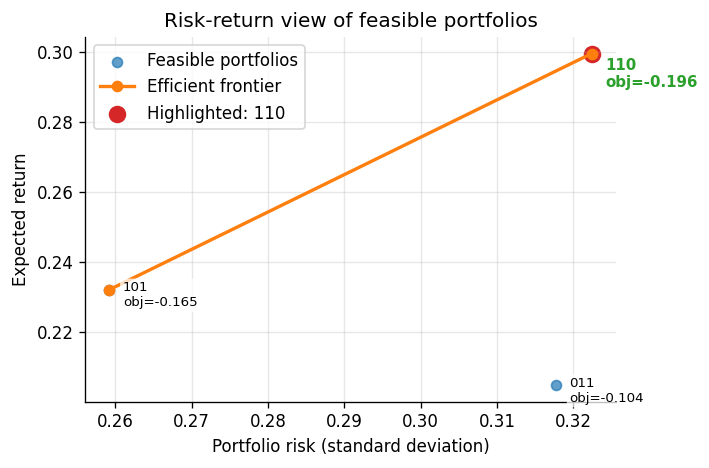

In [14]:
classical_preview = bruteforce_portfolio_baseline(active_example["mu"], active_example["Sigma"], active_example["q"], active_example["B"], active_example["lam"])
const, linear, quad = portfolio_qubo_coeffs(active_example["mu"], active_example["Sigma"], active_example["q"], active_example["B"], active_example["lam"])
c0, z_coeffs, zz_coeffs = qubo_to_ising(const, linear, quad)
cost_operator = build_qiskit_cost_operator(c0, z_coeffs, zz_coeffs)
ising_check = compare_analytical_and_numerical_ising(active_example["mu"], active_example["Sigma"], active_example["q"], active_example["B"], active_example["lam"])

print("Classical best feasible portfolio:")
pprint(classical_preview["best_feasible"])
print("\nClassical best penalized portfolio:")
pprint(classical_preview["best_penalized"])
print("\nMax analytical-vs-numerical Ising differences:")
pprint(ising_check["max_abs_diff"])

finance_fig, finance_ax = plt.subplots(figsize=(6, 4))
plot_risk_return_scatter(classical_preview, show_frontier=True, ax=finance_ax)
finance_fig.tight_layout()
if RUN_LOCAL_VERIFICATION:
    record_artifact("phase1_finance_plot", save_figure_artifact(finance_fig, RUN_OUTPUT_DIR, "phase1_finance.png"))
plt.show()


## 4. Local QAOA verification run


In [15]:
if RUN_LOCAL_VERIFICATION:
    local_result = run_qaoa_experiment_qiskit(
        mu=local_verification_config["mu"], Sigma=local_verification_config["Sigma"], q=local_verification_config["q"],
        B=local_verification_config["B"], lam=local_verification_config["lam"], p=local_verification_config["p"],
        shots=local_verification_config["shots"], n_steps=local_verification_config["n_steps"],
        stepsize=local_verification_config["stepsize"], seed=local_verification_config["seed"],
        optimizer_name=local_verification_config["optimizer_name"], execution_mode="local_optimize_hardware_sample",
        sampling_mode="statevector",
    )
    print("Local verification completed.")
    print("Final expected cost =", local_result["optimization"]["final_expected_cost"])
    print("Feasible sample rate =", local_result["samples"]["feasible_sample_rate"])
    print("Probability of the classical optimum =", local_result["samples"]["classical_best_feasible_prob"])
else:
    print("Set RUN_LOCAL_VERIFICATION = True to execute Phase 1.")


Local verification completed.
Final expected cost = -0.11023305601856875
Feasible sample rate = 0.88
Probability of the classical optimum = 0.28


## 5. Local result plots and summaries


Classical best feasible portfolio:
{'bitstring': (1, 1, 0),
 'bitstring_str': '110',
 'expected_return': 0.29953219687391014,
 'is_feasible': True,
 'penalized_objective': -0.1955956530992681,
 'penalty': 0.0,
 'raw_objective': -0.1955956530992681,
 'selected_assets': 2,
 'stdev': 0.32239191021897873,
 'variance': 0.10393654377464204}

Local QAOA summary:
{'backend': None,
 'best_feasible_sampled_bitstring': '110',
 'best_feasible_sampled_objective': -0.1955956530992681,
 'best_sampled_bitstring': '110',
 'best_sampled_objective': -0.1955956530992681,
 'classical_optimum_probability': 0.28,
 'feasible_sample_rate': 0.88,
 'final_expected_cost': -0.11023305601856875,
 'mode': 'phase1_local_verification',
 'run_id': 'ibm_rollout_20260415_192343',
 'runtime_sec': 3.307740600001125}

Top sampled portfolios:
{'bitstring': (0, 1, 1),
 'bitstring_str': '011',
 'count': 17,
 'expected_return': 0.20496359419034202,
 'is_feasible': True,
 'penalized_objective': -0.1039975139391429,
 'penalty': 0

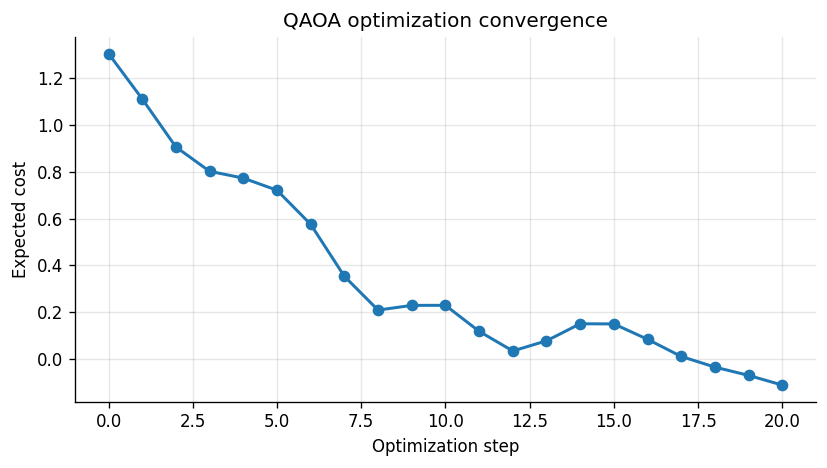

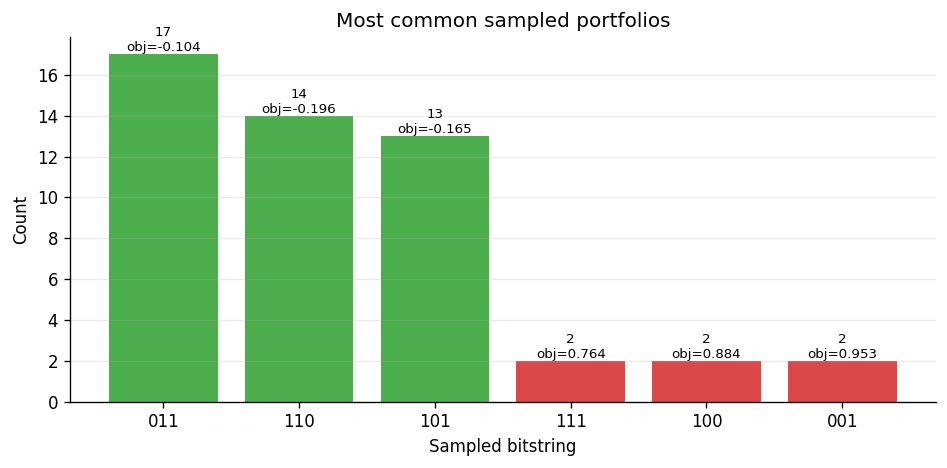

In [16]:
if local_result is None:
    print("Phase 1 local verification was skipped, so there are no local plots or saved local artifacts.")
else:
    phase1_config = config_payload(local_result["config"], execution_mode="local_optimize_hardware_sample", backend_name=local_result["hardware"].get("backend_name"))
    phase1_summary = summarize_run_for_logging(local_result, RUN_ID, mode_label="phase1_local_verification")
    record_artifact("phase1_local_config_json", save_json_artifact(phase1_config, RUN_OUTPUT_DIR, "phase1_local_config.json"))
    record_artifact("phase1_local_summary_json", save_json_artifact(phase1_summary, RUN_OUTPUT_DIR, "phase1_local_summary.json"))
    record_artifact("phase1_local_counts_json", save_json_artifact({"run_id": RUN_ID, "counts": local_result["samples"]["counts_from_backend"]}, RUN_OUTPUT_DIR, "phase1_local_counts.json"))
    record_summary("phase1_local_verification", phase1_summary)

    print("Classical best feasible portfolio:")
    pprint(local_result["classical"]["best_feasible"])
    print("\nLocal QAOA summary:")
    pprint(phase1_summary)
    print("\nTop sampled portfolios:")
    for record in local_result["samples"]["top_sampled"][:8]:
        pprint(record)
    print("\nFinance plot saved to:", artifact_manifest["files"].get("phase1_finance_plot"))

    convergence_fig, convergence_ax = plt.subplots(figsize=(7, 4))
    plot_optimization_convergence(local_result, ax=convergence_ax)
    convergence_fig.tight_layout()
    record_artifact("phase1_convergence_plot", save_figure_artifact(convergence_fig, RUN_OUTPUT_DIR, "phase1_convergence.png"))
    plt.show()

    local_hist_fig, local_hist_ax = plt.subplots(figsize=(8, 4))
    plot_bitstring_distribution(local_result, top_k=8, ax=local_hist_ax)
    local_hist_fig.tight_layout()
    record_artifact("phase1_local_bitstrings_plot", save_figure_artifact(local_hist_fig, RUN_OUTPUT_DIR, "phase1_local_bitstrings.png"))
    plt.show()


## 6. Hardware final-sampling run


In [17]:
if RUN_IBM_FINAL_SAMPLING:
    if local_result is None:
        raise ValueError("Phase 1 local verification must run first so Phase 2 can reuse the optimized parameters.")

    runtime_service = get_ibm_runtime_service(channel=runtime_defaults["channel"], instance=hardware_final_sampling_config["runtime_instance"])
    selected_backend = select_ibm_backend(service=runtime_service, backend_name=hardware_final_sampling_config["backend_name"], min_num_qubits=len(active_example["mu"]), instance=hardware_final_sampling_config["runtime_instance"])
    phase2_started = time.perf_counter()

    bound_info = build_bound_measured_qaoa_circuit(cost_operator=cost_operator, n_qubits=len(active_example["mu"]), p=local_verification_config["p"], parameter_values=local_result["optimization"]["optimized_params"])
    phase2_diagnostics = summarize_transpiled_circuit(bound_info["bound_circuit"], selected_backend)
    phase2_diagnostics_to_save = strip_transpiled_circuit(phase2_diagnostics)
    record_artifact("phase2_transpilation_diagnostics_json", save_json_artifact(phase2_diagnostics_to_save, RUN_OUTPUT_DIR, "phase2_transpilation_diagnostics.json"))

    local_fixed_sampling = sample_fixed_qaoa_circuit(cost_operator=cost_operator, n_qubits=len(active_example["mu"]), p=local_verification_config["p"], parameter_values=local_result["optimization"]["optimized_params"], shots=hardware_final_sampling_config["shots"], sampling_mode="statevector", seed=local_verification_config["seed"])
    ibm_fixed_sampling = sample_fixed_qaoa_circuit(cost_operator=cost_operator, n_qubits=len(active_example["mu"]), p=local_verification_config["p"], parameter_values=local_result["optimization"]["optimized_params"], shots=hardware_final_sampling_config["shots"], sampling_mode="runtime", backend=selected_backend, runtime_service=runtime_service, runtime_instance=hardware_final_sampling_config["runtime_instance"])
    phase2_runtime_sec = float(time.perf_counter() - phase2_started)

    local_phase2_metrics = extract_sampling_metrics(counts_to_samples(local_fixed_sampling["counts"], len(active_example["mu"])), active_example["mu"], active_example["Sigma"], active_example["q"], active_example["B"], active_example["lam"], classical_preview)
    ibm_phase2_metrics = extract_sampling_metrics(counts_to_samples(ibm_fixed_sampling["counts"], len(active_example["mu"])), active_example["mu"], active_example["Sigma"], active_example["q"], active_example["B"], active_example["lam"], classical_preview)
    local_empirical_average_penalized_cost = empirical_average_penalized_cost_from_counts(local_fixed_sampling["counts"], active_example["mu"], active_example["Sigma"], active_example["q"], active_example["B"], active_example["lam"])
    ibm_empirical_average_penalized_cost = empirical_average_penalized_cost_from_counts(ibm_fixed_sampling["counts"], active_example["mu"], active_example["Sigma"], active_example["q"], active_example["B"], active_example["lam"])
    phase2_result = {
        "backend_name": phase2_diagnostics_to_save["backend_name"],
        "shots": hardware_final_sampling_config["shots"],
        "local_sampling": local_fixed_sampling,
        "ibm_sampling": ibm_fixed_sampling,
        "local_metrics": local_phase2_metrics,
        "ibm_metrics": ibm_phase2_metrics,
        "local_empirical_average_penalized_cost": local_empirical_average_penalized_cost,
        "ibm_empirical_average_penalized_cost": ibm_empirical_average_penalized_cost,
        "runtime_sec": phase2_runtime_sec,
        "job_id": ibm_fixed_sampling["metadata"].get("job_id"),
    }

    phase2_config = config_payload({**local_result["config"], "shots": hardware_final_sampling_config["shots"]}, execution_mode="local_optimize_hardware_sample", backend_name=phase2_result["backend_name"], shots=hardware_final_sampling_config["shots"])
    phase2_summary = summary_from_metrics("phase2_hardware_final_sampling", phase2_result["backend_name"], ibm_phase2_metrics, final_expected_cost=local_result["optimization"]["final_expected_cost"], runtime_sec=phase2_runtime_sec, job_id=phase2_result["job_id"], empirical_average_penalized_cost=ibm_empirical_average_penalized_cost)

    record_artifact("phase2_hardware_config_json", save_json_artifact(phase2_config, RUN_OUTPUT_DIR, "phase2_hardware_config.json"))
    record_artifact("phase2_local_reference_counts_json", save_json_artifact({"run_id": RUN_ID, "counts": local_fixed_sampling["counts"]}, RUN_OUTPUT_DIR, "phase2_local_counts.json"))
    record_artifact("phase2_hardware_counts_json", save_json_artifact({"run_id": RUN_ID, "job_id": phase2_result["job_id"], "counts": ibm_fixed_sampling["counts"]}, RUN_OUTPUT_DIR, "phase2_hardware_counts.json"))
    record_artifact("phase2_hardware_summary_json", save_json_artifact(phase2_summary, RUN_OUTPUT_DIR, "phase2_hardware_summary.json"))
    record_summary("phase2_hardware_final_sampling", phase2_summary)

    print("Chosen backend =", phase2_result["backend_name"])
    print("IBM job ID =", phase2_result["job_id"])
    print("Shots =", phase2_result["shots"])
    print("Transpiled depth =", phase2_diagnostics_to_save["transpiled_depth"])
    print("2-qubit gate count =", phase2_diagnostics_to_save["two_qubit_gate_count"])
    print("Local empirical average penalized objective =", local_empirical_average_penalized_cost)
    print("IBM empirical average penalized objective =", ibm_empirical_average_penalized_cost)
else:
    print("Set RUN_IBM_FINAL_SAMPLING = True to run Phase 2 after the local verification step.")


Set RUN_IBM_FINAL_SAMPLING = True to run Phase 2 after the local verification step.


## 7. Hardware result plots and summaries


In [18]:
if phase2_result is None:
    print("Phase 2 was skipped, so there are no IBM result plots to display.")
else:
    local_reference_summary = summary_from_metrics("phase2_local_reference", "local_statevector", phase2_result["local_metrics"], final_expected_cost=local_result["optimization"]["final_expected_cost"], empirical_average_penalized_cost=phase2_result["local_empirical_average_penalized_cost"])
    print("IBM final-sampling summary:")
    pprint(artifact_manifest["summaries"]["phase2_hardware_final_sampling"])
    print("IBM empirical average penalized objective from sampled counts =", phase2_result["ibm_empirical_average_penalized_cost"])
    print("\nLocal fixed-parameter reference summary:")
    pprint(local_reference_summary)
    print("Local empirical average penalized objective from sampled counts =", phase2_result["local_empirical_average_penalized_cost"])

    ibm_hist_fig, ibm_hist_ax = plt.subplots(figsize=(8, 4))
    plot_bitstring_distribution({"samples": {"top_sampled": phase2_result["ibm_metrics"]["top_sampled"]}}, top_k=8, ax=ibm_hist_ax)
    ibm_hist_ax.set_title("IBM final sampled portfolios")
    ibm_hist_fig.tight_layout()
    record_artifact("phase2_ibm_bitstrings_plot", save_figure_artifact(ibm_hist_fig, RUN_OUTPUT_DIR, "phase2_ibm_bitstrings.png"))
    plt.show()

    compare_fig, compare_ax = plt.subplots(figsize=(9, 4))
    plot_local_vs_ibm_probability_comparison(phase2_result["local_sampling"]["counts"], phase2_result["ibm_sampling"]["counts"], ax=compare_ax, title="Local vs IBM sampled probabilities")
    compare_fig.tight_layout()
    record_artifact("phase2_local_vs_ibm_probabilities_plot", save_figure_artifact(compare_fig, RUN_OUTPUT_DIR, "phase2_local_vs_ibm_probabilities.png"))
    plt.show()


Phase 2 was skipped, so there are no IBM result plots to display.


## 8. Transpilation diagnostics / hardware cost estimation


In [19]:
tiny_loop_estimate = estimate_hardware_loop_cost(p=tiny_hardware_loop_config["p"], shots=tiny_hardware_loop_config["shots"], n_steps=tiny_hardware_loop_config["n_steps"])
if phase2_diagnostics is None:
    print("Phase 2 diagnostics are not available yet. Enable RUN_IBM_FINAL_SAMPLING to generate them.")
else:
    print("Phase 2 transpilation diagnostics:")
    pprint(strip_transpiled_circuit(phase2_diagnostics))
    print("\nDiagnostics JSON saved to:")
    print(artifact_manifest["files"].get("phase2_transpilation_diagnostics_json"))

print("\nTiny hardware-in-loop cost estimate:")
pprint(tiny_loop_estimate)
print("\nOpen Plan warnings for the tiny hardware-in-loop configuration:")
for warning in hardware_loop_warnings(tiny_hardware_loop_config["n_assets"], tiny_hardware_loop_config["p"], tiny_hardware_loop_config["shots"], tiny_hardware_loop_config["n_steps"]):
    print(" -", warning)


Phase 2 diagnostics are not available yet. Enable RUN_IBM_FINAL_SAMPLING to generate them.

Tiny hardware-in-loop cost estimate:
{'estimated_ibm_jobs': 181,
 'estimated_objective_evaluations': 181,
 'estimated_total_shots': 9050,
 'n_parameters': 6}

Open Plan warnings for the tiny hardware-in-loop configuration:
 - QAOA depth p > 2 may consume Open Plan budget quickly.
 - n_steps > 10 may be too expensive for hardware-in-loop optimization.


## 9. Optional tiny hardware-in-loop run


Running tiny hardware-in-loop with n_assets = 3, p = 3, shots = 50, n_steps = 60


qiskit_runtime_service.__init__:WARNING:2026-04-15 19:23:52,255: Instance was not set at service instantiation. Based on the following filters: (tags: None, region: us-east, plans_preference: open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-15 19:23:52,761: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-04-15 19:23:54,886: Using instance: open-instance, plan: open


Chosen backend = ibm_fez
Initial transpiled diagnostics:
{'backend_name': 'ibm_fez',
 'circuit_width': 156,
 'logical_n_qubits': 3,
 'parameter_values': [1.9637953256775056,
                      2.818680285825393,
                      2.436888465969028,
                      0.7075092536100441,
                      0.9430001955324466,
                      2.7443490865749487],
 'resource_summary': {'count_ops': {'cz': 28,
                                    'measure': 3,
                                    'rz': 60,
                                    'sx': 68,
                                    'x': 8},
                      'depth': 112,
                      'size': 167,
                      'two_qubit_gate_count': 28},
 'total_gate_counts': {'cz': 28, 'measure': 3, 'rz': 60, 'sx': 68, 'x': 8},
 'transpiled_depth': 112,
 'transpiled_size': 167,
 'two_qubit_gate_breakdown': {'cz': 28},
 'two_qubit_gate_count': 28}
Saved to: C:\Users\anton\Documents\VSCODE PROJECTS\QAOA\IBM\outpu

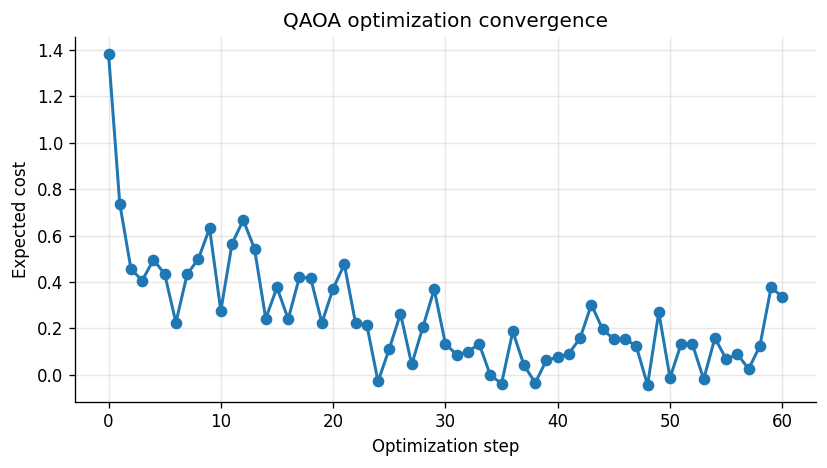

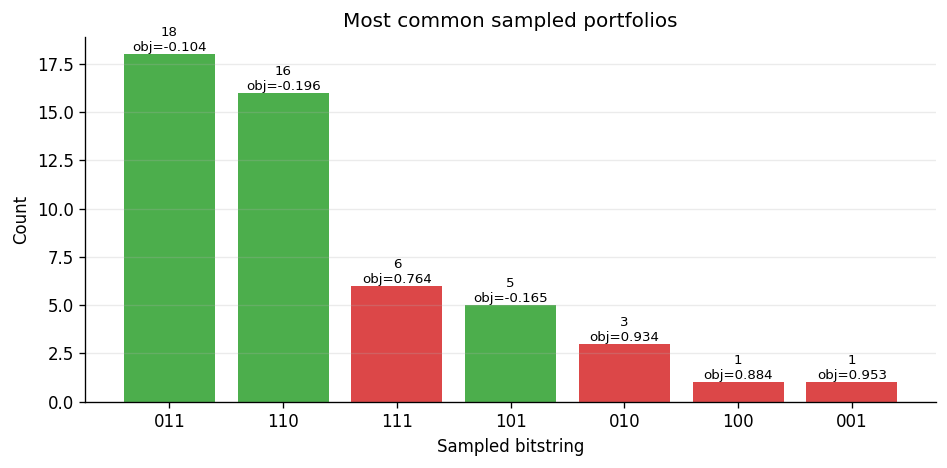

In [20]:
if RUN_HARDWARE_IN_LOOP:
    import importlib
    import portfolio_qaoa_qiskit as qiskit_utils
    qiskit_utils = importlib.reload(qiskit_utils)
    print("Running tiny hardware-in-loop with n_assets = {0}, p = {1}, shots = {2}, n_steps = {3}".format(tiny_hardware_loop_config["n_assets"], tiny_hardware_loop_config["p"], tiny_hardware_loop_config["shots"], tiny_hardware_loop_config["n_steps"]))
    for warning in hardware_loop_warnings(tiny_hardware_loop_config["n_assets"], tiny_hardware_loop_config["p"], tiny_hardware_loop_config["shots"], tiny_hardware_loop_config["n_steps"]):
        print("Warning:", warning)

    runtime_service = get_ibm_runtime_service(channel=runtime_defaults["channel"], instance=tiny_hardware_loop_config["runtime_instance"])
    selected_backend = select_ibm_backend(service=runtime_service, backend_name=tiny_hardware_loop_config["backend_name"], min_num_qubits=tiny_hardware_loop_config["n_assets"], instance=tiny_hardware_loop_config["runtime_instance"])
    tiny_const, tiny_linear, tiny_quad = portfolio_qubo_coeffs(tiny_hardware_loop_config["mu"], tiny_hardware_loop_config["Sigma"], tiny_hardware_loop_config["q"], tiny_hardware_loop_config["B"], tiny_hardware_loop_config["lam"])
    tiny_c0, tiny_z, tiny_zz = qubo_to_ising(tiny_const, tiny_linear, tiny_quad)
    tiny_cost_operator = build_qiskit_cost_operator(tiny_c0, tiny_z, tiny_zz)
    phase3_initial_params = qiskit_utils.generate_initial_qaoa_parameters(tiny_hardware_loop_config["p"], seed=tiny_hardware_loop_config["seed"])
    phase3_initial_diagnostics = qiskit_utils.summarize_transpiled_bound_qaoa_circuit(
        cost_operator=tiny_cost_operator,
        n_qubits=tiny_hardware_loop_config["n_assets"],
        p=tiny_hardware_loop_config["p"],
        parameter_values=phase3_initial_params,
        backend=selected_backend,
    )
    phase3_initial_diagnostics_to_save = strip_transpiled_circuit(phase3_initial_diagnostics)
    record_artifact("phase3_transpile_initial_json", save_json_artifact(phase3_initial_diagnostics_to_save, RUN_OUTPUT_DIR, "phase3_transpile_initial.json"))

    phase3_result = run_qaoa_experiment_qiskit(
        mu=tiny_hardware_loop_config["mu"], Sigma=tiny_hardware_loop_config["Sigma"], q=tiny_hardware_loop_config["q"],
        B=tiny_hardware_loop_config["B"], lam=tiny_hardware_loop_config["lam"], p=tiny_hardware_loop_config["p"],
        shots=tiny_hardware_loop_config["shots"], n_steps=tiny_hardware_loop_config["n_steps"],
        stepsize=tiny_hardware_loop_config["stepsize"], seed=tiny_hardware_loop_config["seed"],
        optimizer_name=tiny_hardware_loop_config["optimizer_name"], execution_mode="hardware_in_loop",
        sampling_mode="runtime", backend=selected_backend, runtime_service=runtime_service,
        runtime_instance=tiny_hardware_loop_config["runtime_instance"], allow_hardware_loop=True,
    )
    phase3_final_diagnostics = qiskit_utils.summarize_transpiled_bound_qaoa_circuit(
        cost_operator=tiny_cost_operator,
        n_qubits=tiny_hardware_loop_config["n_assets"],
        p=tiny_hardware_loop_config["p"],
        parameter_values=phase3_result["optimization"]["optimized_params"],
        backend=selected_backend,
    )
    phase3_final_diagnostics_to_save = strip_transpiled_circuit(phase3_final_diagnostics)
    record_artifact("phase3_transpile_final_json", save_json_artifact(phase3_final_diagnostics_to_save, RUN_OUTPUT_DIR, "phase3_transpile_final.json"))
    phase3_config = config_payload(phase3_result["config"], execution_mode="hardware_in_loop", backend_name=phase3_result["hardware"].get("backend_name"))
    phase3_summary = summarize_run_for_logging(phase3_result, RUN_ID, mode_label="phase3_hardware_in_loop")
    record_artifact("phase3_hardware_config_json", save_json_artifact(phase3_config, RUN_OUTPUT_DIR, "phase3_hardware_config.json"))
    record_artifact("phase3_hardware_summary_json", save_json_artifact(phase3_summary, RUN_OUTPUT_DIR, "phase3_hardware_summary.json"))
    record_artifact("phase3_hardware_counts_json", save_json_artifact({"run_id": RUN_ID, "counts": phase3_result["samples"]["counts_from_backend"]}, RUN_OUTPUT_DIR, "phase3_hardware_counts.json"))
    record_summary("phase3_hardware_in_loop", phase3_summary)

    print("Chosen backend =", phase3_result["hardware"].get("backend_name"))
    print("Initial transpiled diagnostics:")
    pprint(phase3_initial_diagnostics_to_save)
    print("Saved to:", artifact_manifest["files"].get("phase3_transpile_initial_json"))
    print("\nFinal transpiled diagnostics:")
    pprint(phase3_final_diagnostics_to_save)
    print("Saved to:", artifact_manifest["files"].get("phase3_transpile_final_json"))
    print("\nHardware-in-loop summary:")
    pprint(phase3_summary)

    phase3_convergence_fig, phase3_convergence_ax = plt.subplots(figsize=(7, 4))
    plot_optimization_convergence(phase3_result, ax=phase3_convergence_ax)
    phase3_convergence_fig.tight_layout()
    record_artifact("phase3_convergence_plot", save_figure_artifact(phase3_convergence_fig, RUN_OUTPUT_DIR, "phase3_convergence.png"))
    plt.show()

    phase3_hist_fig, phase3_hist_ax = plt.subplots(figsize=(8, 4))
    plot_bitstring_distribution(phase3_result, top_k=8, ax=phase3_hist_ax)
    phase3_hist_fig.tight_layout()
    record_artifact("phase3_hardware_bitstrings_plot", save_figure_artifact(phase3_hist_fig, RUN_OUTPUT_DIR, "phase3_hardware_bitstrings.png"))
    plt.show()
else:
    print("Set RUN_HARDWARE_IN_LOOP = True only after Phase 2 looks affordable on IBM Open Plan.")


## 10. Saved outputs / run logging summary


In [21]:
artifact_manifest_path = str((RUN_OUTPUT_DIR / "artifact_manifest.json").resolve())
artifact_manifest["files"]["artifact_manifest_json"] = artifact_manifest_path
save_json_artifact(artifact_manifest, RUN_OUTPUT_DIR, "artifact_manifest.json")

print("Run output directory:", RUN_OUTPUT_DIR)
print("\nSaved artifacts:")
for key, path in artifact_manifest["files"].items():
    print(f" - {key}: {path}")

print("\nSaved summaries:")
for key, summary in artifact_manifest["summaries"].items():
    print(f"\n{key}:")
    pprint(summary)


Run output directory: C:\Users\anton\Documents\VSCODE PROJECTS\QAOA\IBM\outputs\ibm_runs\ibm_rollout_20260415_192343

Saved artifacts:
 - phase1_finance_plot: C:\Users\anton\Documents\VSCODE PROJECTS\QAOA\IBM\outputs\ibm_runs\ibm_rollout_20260415_192343\phase1_finance.png
 - phase1_local_config_json: C:\Users\anton\Documents\VSCODE PROJECTS\QAOA\IBM\outputs\ibm_runs\ibm_rollout_20260415_192343\phase1_local_config.json
 - phase1_local_summary_json: C:\Users\anton\Documents\VSCODE PROJECTS\QAOA\IBM\outputs\ibm_runs\ibm_rollout_20260415_192343\phase1_local_summary.json
 - phase1_local_counts_json: C:\Users\anton\Documents\VSCODE PROJECTS\QAOA\IBM\outputs\ibm_runs\ibm_rollout_20260415_192343\phase1_local_counts.json
 - phase1_convergence_plot: C:\Users\anton\Documents\VSCODE PROJECTS\QAOA\IBM\outputs\ibm_runs\ibm_rollout_20260415_192343\phase1_convergence.png
 - phase1_local_bitstrings_plot: C:\Users\anton\Documents\VSCODE PROJECTS\QAOA\IBM\outputs\ibm_runs\ibm_rollout_20260415_192343\phas